In [1]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
sns.set_context('notebook')
%config InlineBackend.figure_format = 'retina'   # or 'png'
%config InlineBackend.rc = {'figure.dpi': 92}    # force dpi


from utils.setup_environment import *
from utils.Glider1D import Glider1D, CustomStimuli, RenderedData
from utils.glider_utils import *

from flyvis.utils.activity_utils import LayerActivity


In [2]:
network_view = flyvis.NetworkView(flyvis.results_dir / "flow/0000/000")
network = network_view.init_network()

[2025-10-30 22:27:41] network_view:122 Initialized network view at /home/guardomayas/flyvis_data/results/flow/0000/000
[2025-10-30 22:27:45] network:222 Initialized network with NumberOfParams(free=734, fixed=2959) parameters.
[2025-10-30 22:27:45] chkpt_utils:36 Recovered network state.


In [8]:
rules = ['uniform_edge', '2pt', '3pt_Conv', '3pt_Div', 'uncorrelated']
seeds = [1, 20, 30, 55, 65]  
fps = 24
T = fps * 3
dt = 1 / 100
x_resol = 98
omm_spacing = 5.8
vel = 74
dpp = 2.25
k_size = int(np.ceil(omm_spacing/dpp))
k_size 

3

-------- Seed: 1 --------


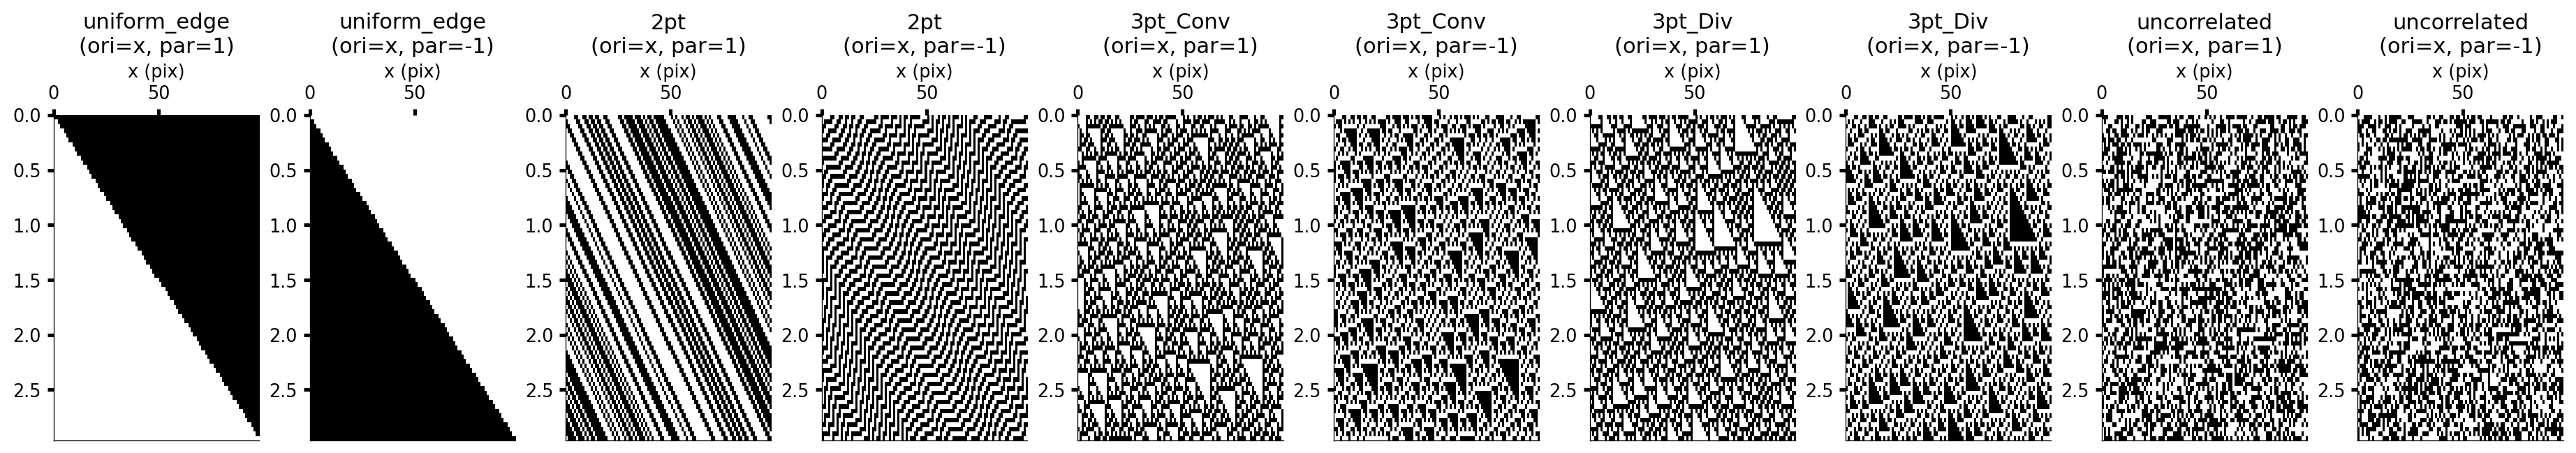

Created movie_input for 20 sequences, shape = torch.Size([300, 20, 721])
Simulation complete! Final responses shape: torch.Size([20, 300, 45669])
-------- Seed: 20 --------


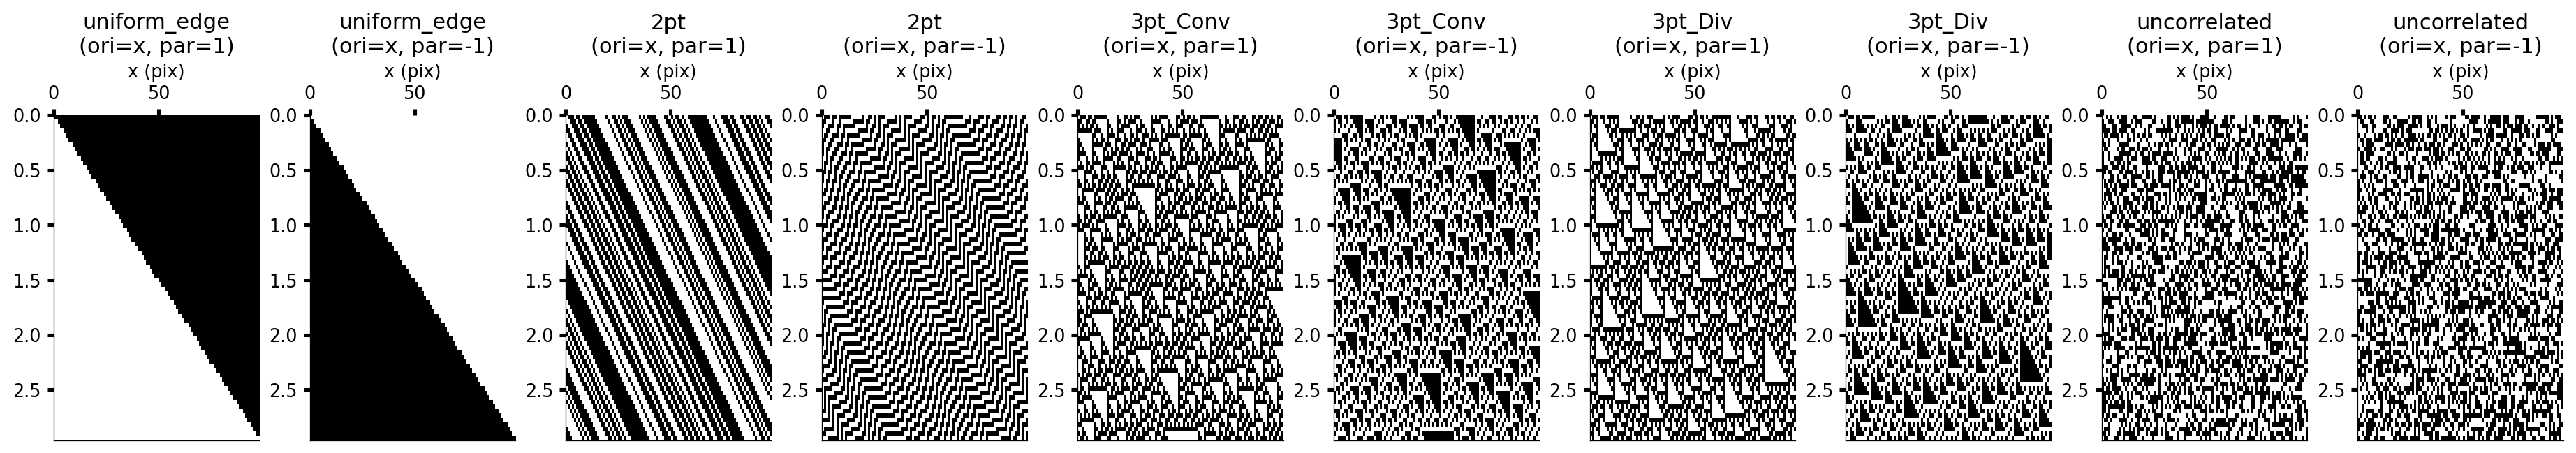

Created movie_input for 20 sequences, shape = torch.Size([300, 20, 721])
Simulation complete! Final responses shape: torch.Size([20, 300, 45669])
-------- Seed: 30 --------
Inverting contrast for uncorrelated stimulus.
Inverting contrast for uncorrelated stimulus.


Rendering glider → hex: 100%|██████████| 20/20 [00:00<00:00, 42.35it/s]


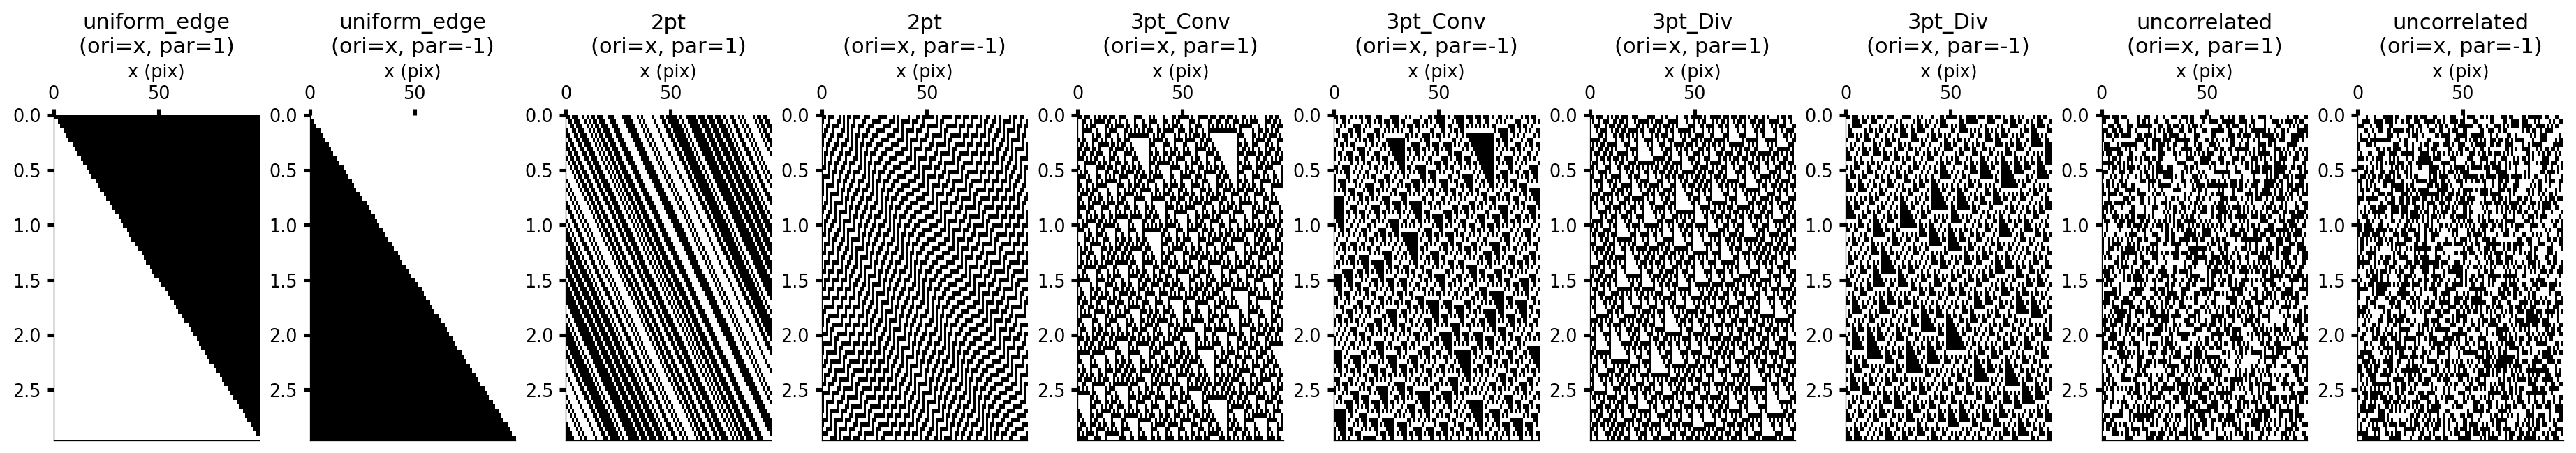

Created movie_input for 20 sequences, shape = torch.Size([300, 20, 721])
Simulation complete! Final responses shape: torch.Size([20, 300, 45669])
-------- Seed: 55 --------
Inverting contrast for uncorrelated stimulus.
Inverting contrast for uncorrelated stimulus.


Rendering glider → hex: 100%|██████████| 20/20 [00:00<00:00, 91.49it/s]


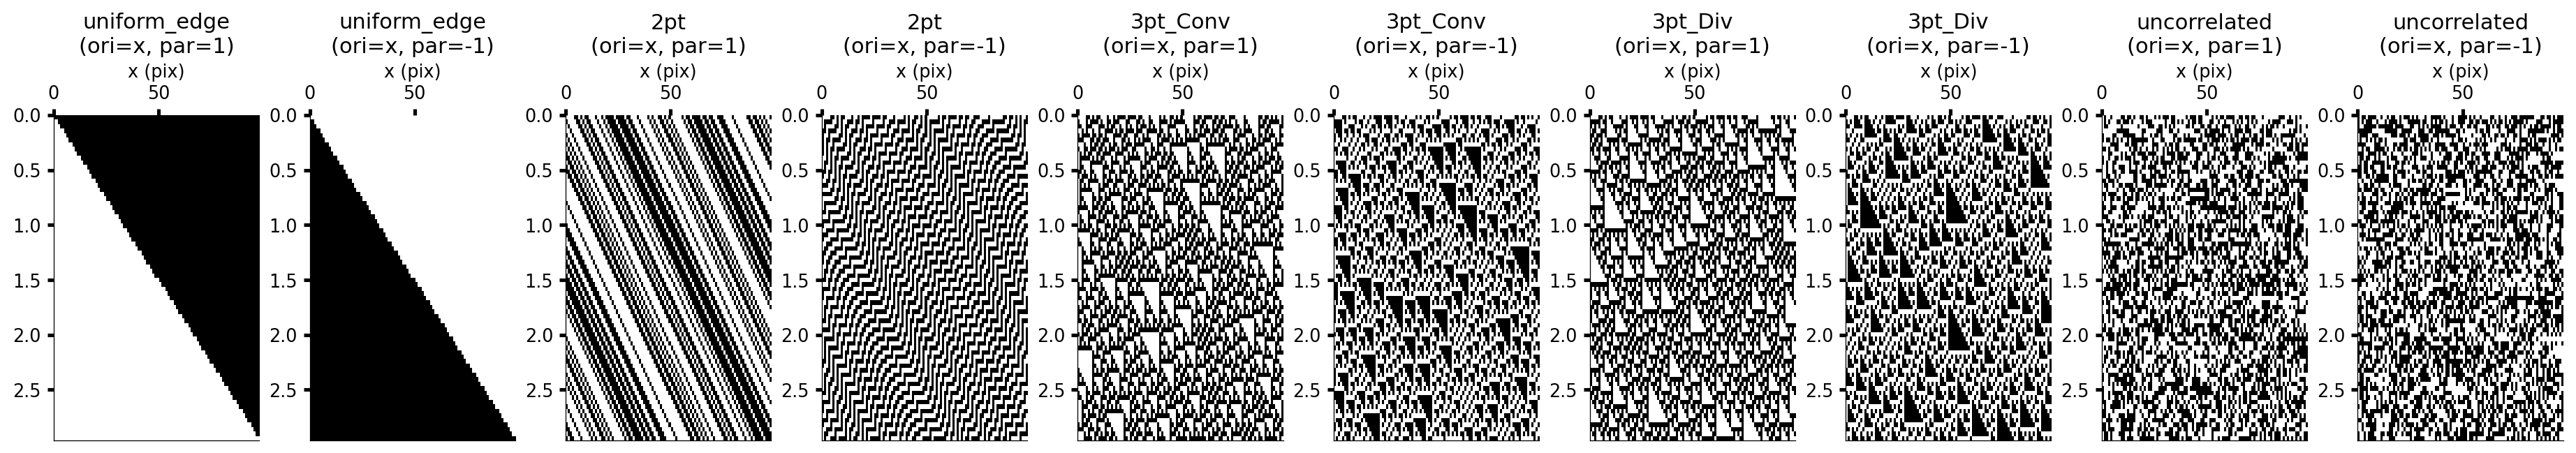

Created movie_input for 20 sequences, shape = torch.Size([300, 20, 721])
Simulation complete! Final responses shape: torch.Size([20, 300, 45669])
-------- Seed: 65 --------
Inverting contrast for uncorrelated stimulus.
Inverting contrast for uncorrelated stimulus.


Rendering glider → hex: 100%|██████████| 20/20 [00:00<00:00, 66.56it/s]


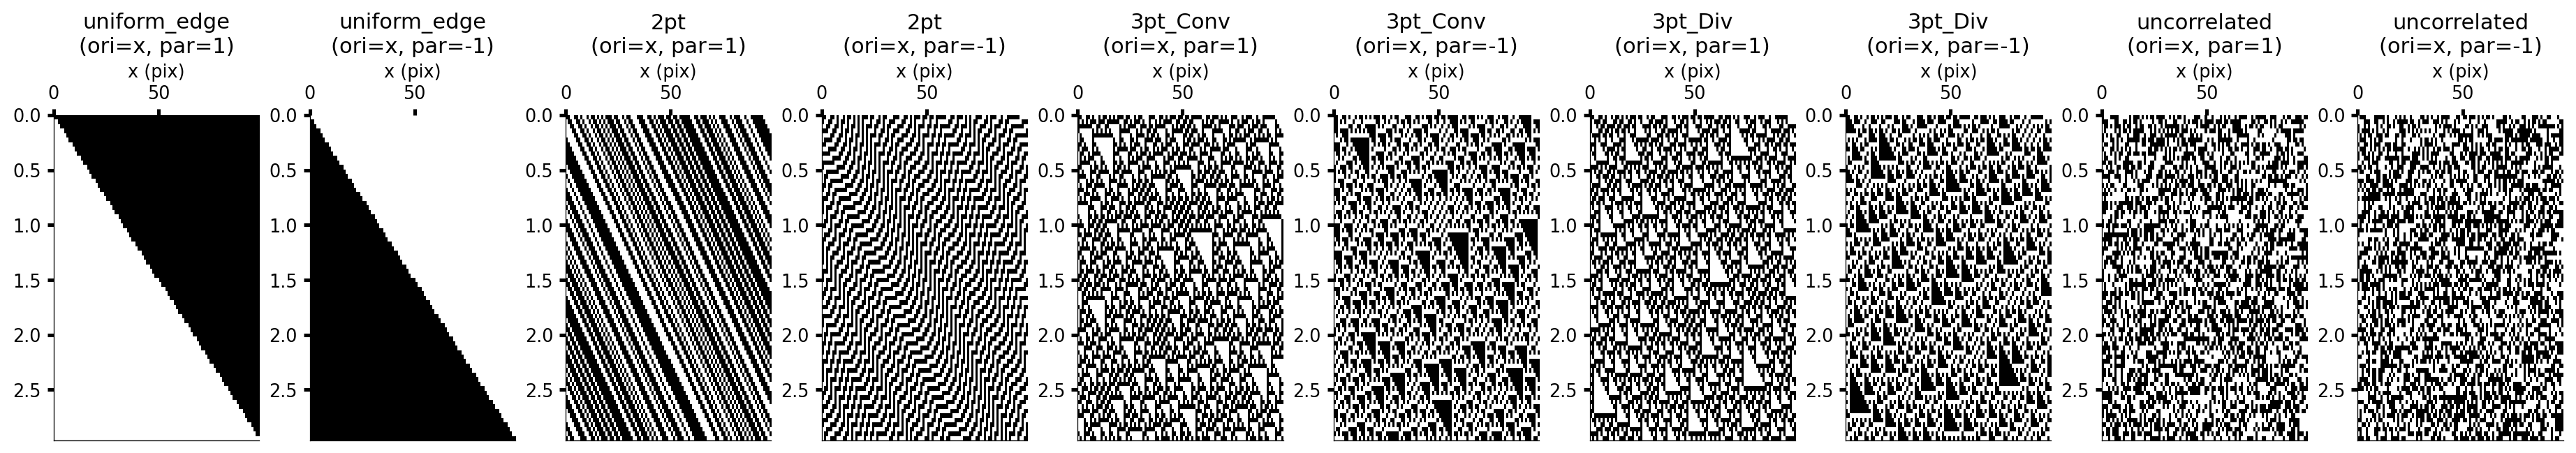

Created movie_input for 20 sequences, shape = torch.Size([300, 20, 721])
Simulation complete! Final responses shape: torch.Size([20, 300, 45669])


In [9]:
fs = 12
tickwidth = 2

responses = []
df_metadata = []

for seed in seeds:
    print(f"-------- Seed: {seed} --------")
    data = CustomStimuli(
        dict(
            extent=15,
            kernel_size=k_size,
            x_resol=x_resol,
            T=T,
            rules=rules,
            directions=["pd", "nd"],
            parities=[1, -1],
            vel=vel,
            seed=seed,
            orientations=['x'],
            subset_idx=[]
        ),
        dt=dt,
        original_framerate=fps,
        dpp=dpp  # <-- Add dpp as a direct, top-level argument
    )
    n_seqs = data.cartesian_sequences.shape[0]
    t_ax = np.arange(T) / fps
    pd_idx = data.arg_df.query("direction == 'pd'")['sequence_idx'].values
    n_pd = len(pd_idx)

    # Create the figure and axes *once*
    fig, ax = plt.subplots(1, n_pd, figsize=(2.0 * n_pd, 3.5))

    if n_pd == 1:
        ax = [ax] 

    # Loop to draw on each axis
    for j, i in enumerate(pd_idx):
        meta = data.arg_df.loc[i]
        orientation = meta['orientation']
        
        if orientation == 'x':
            y_slice = data.cartesian_sequences.shape[2] // 2
            patch = data.cartesian_sequences[i, :, y_slice, :]
            xlabel = 'x'
        else:
            x_slice = data.cartesian_sequences.shape[3] // 2
            patch = data.cartesian_sequences[i, :, :, x_slice]
            xlabel = 'y'

        spatial_res = patch.shape[1]
        
        ax[j].imshow(
            patch,
            origin="upper",
            aspect="auto",
            cmap="gray",
            extent=(0, spatial_res, t_ax[-1], 0)
        )
        
        ax[j].set_xlabel(f"{xlabel} (pix)", fontsize=fs - 2)
        ax[j].xaxis.set_label_position("top")
        ax[j].xaxis.set_ticks_position("top")
        ax[j].tick_params(axis='both', which='major', labelsize=fs - 2, width=tickwidth)
        
        title = f"{meta['rule']}\n(ori={meta['orientation']}, par={meta['parity']})"
        ax[j].set_title(title, fontsize=fs)

    # --- FIX 1: MOVED PLOTTING COMMANDS HERE ---
    # Show the figure *after* the loop is finished
    fig.tight_layout()
    plt.show()
    num_sequences = len(data)
    movie_input = torch.stack([data[i] for i in range(num_sequences)])
    movie_input = movie_input.squeeze(2).permute(1, 0, 2)
    sim_input = movie_input.unsqueeze(2).permute(1, 0, 2, 3)
    print(f"Created movie_input for {num_sequences} sequences, shape = {movie_input.shape}")

    initial_frame = movie_input[[0]].permute(1, 0, 2)
    stationary_state = network.fade_in_state(1.0, data.dt, initial_frame)
    resp = network.simulate(sim_input, data.dt, initial_state=stationary_state).cpu()
    print(f"Simulation complete! Final responses shape: {resp.shape}")

    responses.append(resp)
    meta = data.arg_df.copy()
    meta["seed"] = seed
    meta["T"] = T
    meta["fps"] = fps
    meta["dt"] = dt
    df_metadata.append(meta)

df = pd.concat(df_metadata, ignore_index=True)

In [10]:
responses = np.array([r.numpy() for r in responses])
responses.shape  # (n_seeds, n_sequences, T, n_neurons)

(5, 20, 300, 45669)

In [11]:
# Save responses and df to a .npz file
filename = f'compute_responses/nw_0_gliders_{fps}_fps_{x_resol}_pix_{k_size}_ksize.npz'
np.savez(filename, responses=responses, df=df.to_dict())
print("Data saved to ", filename)
# # Load the saved data
# data_loaded = np.load('compute_responses/nw_0_allgliders_diff_seeds.npz', allow_pickle=True)
# responses = data_loaded['responses']
# df = pd.DataFrame(data_loaded['df'].item())

Data saved to  compute_responses/nw_0_gliders_24_fps_98_pix_3_ksize.npz
